<a href="https://colab.research.google.com/github/Rahulshanth/loan_approval_model/blob/main/Final_Python_Notebook_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import pandas for loading and working with the dataset
import pandas as pd

# import train test split to split data into training and testing
from sklearn.model_selection import train_test_split

# import logistic regression classifier
from sklearn.linear_model import LogisticRegression

# import knn classifier
from sklearn.neighbors import KNeighborsClassifier

# import naive bayes classifier
from sklearn.naive_bayes import GaussianNB

# import gridsearchcv for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# import accuracy score metric
from sklearn.metrics import accuracy_score

# import confusion matrix and display
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# import classification report
from sklearn.metrics import classification_report

# import roc curve display for plotting auc-roc
from sklearn.metrics import RocCurveDisplay

# import other metrics needed
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# import matplotlib for showing plots
import matplotlib.pyplot as plt

print("all libraries imported")

all libraries imported


In [ ]:
# set display options so output doesnt get cut off
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 150)

In [ ]:
# load the prepared classification dataset from notebook 1
data = pd.read_csv('loan_classification_dataset.csv')

# print rows and columns to confirm it loaded correctly
print("dataset loaded")
print(data.shape)

dataset loaded
(58618, 11)


In [ ]:
# show first 15 rows of the dataset
data.head(15)

,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
0,0.015625,0.004114,2,0.000000,1,0.420290,0.088202,0.144578,0,0.071429,0
1,0.015625,0.004747,2,0.048780,1,0.710145,0.637640,0.228916,1,0.035714,0
2,0.046875,0.002848,3,0.121951,3,0.855072,0.393258,0.373494,0,0.035714,0
3,0.312500,0.093788,3,0.073171,1,1.000000,0.144944,0.228916,0,0.321429,0
4,0.312500,0.045258,0,0.073171,2,1.000000,0.393258,0.469880,0,0.428571,0
5,0.312500,0.066887,0,0.219512,5,0.855072,0.139326,0.277108,0,0.392857,0
6,0.312500,0.076907,0,0.219512,0,0.710145,0.363483,0.204819,0,0.321429,0
7,0.312500,0.067412,0,0.073171,2,0.710145,0.640449,0.265060,0,0.535714,0
8,0.312500,0.039983,0,0.048780,0,0.710145,0.271348,0.373494,0,0.321429,0
9,0.312500,0.039983,0,0.219512,5,0.710145,0.744382,0.361446,0,0.535714,0


In [ ]:
# check column names and data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58618 entries, 0 to 58617
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      58618 non-null  float64
 1   income                   58618 non-null  float64
 2   home_ownership           58618 non-null  int64  
 3   emplyment_length         58618 non-null  float64
 4   loan_intent              58618 non-null  int64  
 5   loan_amount              58618 non-null  float64
 6   loan_interest_rate       58618 non-null  float64
 7   loan_income_ratio        58618 non-null  float64
 8   payment_default_on_file  58618 non-null  int64  
 9   credit_history_length    58618 non-null  float64
 10  loan_approval_status     58618 non-null  int64  
dtypes: float64(7), int64(4)
memory usage: 4.9 MB


In [ ]:
# list all the input feature columns to use for classification
# loan_approval_status is the target so it is not included here
feature_cols = ['age', 'income', 'home_ownership', 'emplyment_length',
                'loan_intent', 'loan_amount', 'loan_interest_rate',
                'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']

# assign input features to X
X = data[feature_cols]  # Features

# assign target variable to y
y = data['loan_approval_status']

# print feature names and shape as evidence
print("Feature names used:")
print(feature_cols)
print()
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Feature names used:
['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']

Shape of X: (58618, 10)
Shape of y: (58618,)


In [ ]:
# split data into 80% training and 20% testing
# random_state=42 makes sure all models use the same test instances
# stratify=y keeps the same approved/rejected ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [ ]:
# print sizes to confirm the split worked
print("Training size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print()

Training size: 46894
Test size: 11724



In [ ]:
# check class distribution in training set
print("Class distribution - Training set:")
print(y_train.value_counts())
print()


Class distribution - Training set:
loan_approval_status
0    40218
1     6676
Name: count, dtype: int64



In [ ]:
# check class distribution in test set
print("Class distribution - Test set:")
print(y_test.value_counts())

Class distribution - Test set:
loan_approval_status
0    10055
1     1669
Name: count, dtype: int64


In [ ]:
# create logistic regression model, max_iter increased so it converges properly
logreg = LogisticRegression(max_iter=1000)

# fit the model on training data
logreg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# predict on training set
y_pred_train = logreg.predict(X_train)

In [ ]:
# predict on test set
y_pred = logreg.predict(X_test)

In [ ]:
# create a comparison dataframe of actual vs predicted values
Comparison_df = pd.DataFrame({'Actual' : y_test,  'Predicted' : y_pred})
Comparison_df.head(15)

,Actual,Predicted
34994,0,0
34468,0,0
15745,0,0
4232,1,0
49484,0,0
21866,0,0
38682,0,0
2758,1,0
44533,0,0
29507,0,0


In [ ]:
# calculate training accuracy
accuracy = accuracy_score(y_train, y_pred_train)
print ("the accuracy is: ", accuracy)

the accuracy is:  0.8909242120527147


In [ ]:
# calculate test accuracy
accuracy = accuracy_score(y_test, y_pred)
print ("The accuracy is: ", accuracy)

The accuracy is:  0.8926134425110883


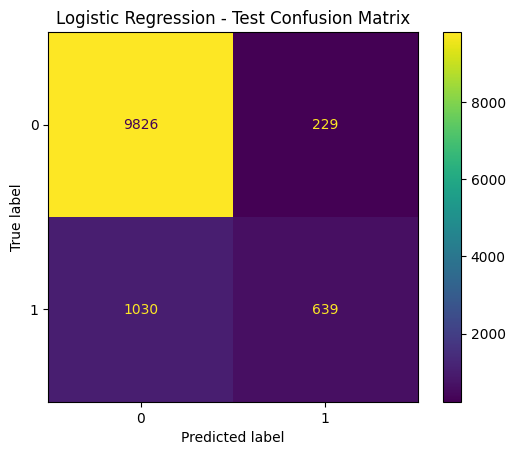

In [ ]:
# create confusion matrix for logistic regression test predictions
cm = confusion_matrix(y_test, y_pred, labels = logreg.classes_)

# display the confusion matrix with class labels
disp = ConfusionMatrixDisplay(cm, display_labels = logreg.classes_)
disp.plot()
plt.title("Logistic Regression - Test Confusion Matrix")
plt.show()

In [ ]:
# print the full classification report for logistic regression
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94     10055
           1       0.74      0.38      0.50      1669

    accuracy                           0.89     11724
   macro avg       0.82      0.68      0.72     11724
weighted avg       0.88      0.89      0.88     11724



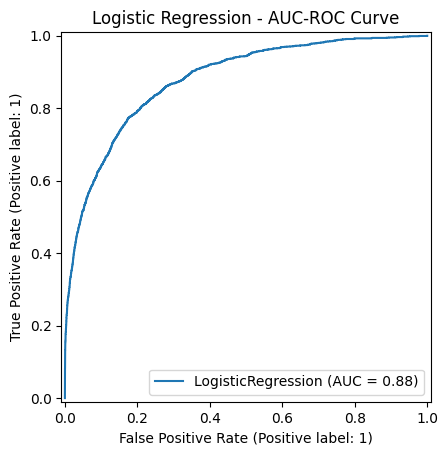

In [ ]:
# plot the auc-roc curve for logistic regression
logreg_roc = RocCurveDisplay.from_estimator(logreg, X_test, y_test)
plt.title("Logistic Regression - AUC-ROC Curve")
plt.show()

In [ ]:
# create gaussian naive bayes model
nb = GaussianNB()

# fit naive bayes on training data
nb.fit(X_train, y_train)

# predict on training set
y_pred_train_nb = nb.predict(X_train)

# predict on test set
y_pred_nb = nb.predict(X_test)

In [ ]:
# compare actual vs predicted for naive bayes
Comparison_df = pd.DataFrame({'Actual' : y_test,  'Predicted' : y_pred_nb})
Comparison_df.head(15)

,Actual,Predicted
34994,0,0
34468,0,0
15745,0,0
4232,1,0
49484,0,0
21866,0,0
38682,0,0
2758,1,0
44533,0,0
29507,0,0


In [ ]:
# training accuracy for naive bayes
accuracy = accuracy_score(y_train, y_pred_train_nb)
print ("the accuracy is: ", accuracy)

the accuracy is:  0.8516014841984049


In [ ]:
# test accuracy for naive bayes
accuracy = accuracy_score(y_test, y_pred_nb)
print ("The accuracy is: ", accuracy)

The accuracy is:  0.8522688502217673


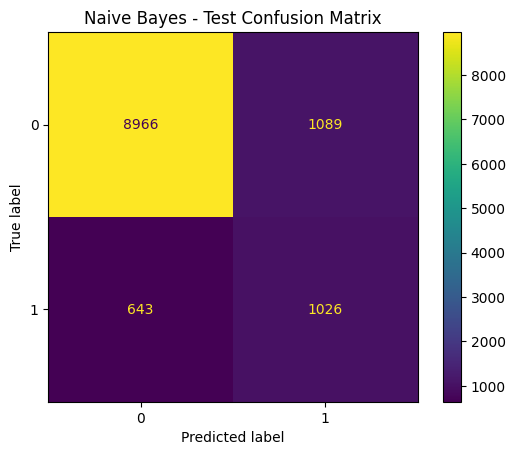

In [ ]:
# confusion matrix for naive bayes
cm = confusion_matrix(y_test, y_pred_nb, labels = nb.classes_)

# display confusion matrix
disp = ConfusionMatrixDisplay(cm, display_labels = nb.classes_)
disp.plot()
plt.title("Naive Bayes - Test Confusion Matrix")
plt.show()

In [ ]:
# classification report for naive bayes
print(classification_report(y_test, y_pred_nb))


              precision    recall  f1-score   support

           0       0.93      0.89      0.91     10055
           1       0.49      0.61      0.54      1669

    accuracy                           0.85     11724
   macro avg       0.71      0.75      0.73     11724
weighted avg       0.87      0.85      0.86     11724



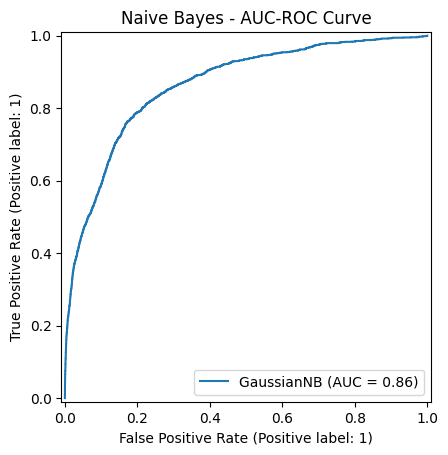

In [ ]:
# auc roc curve for naive bayes
nb_roc = RocCurveDisplay.from_estimator(nb, X_test, y_test)
plt.title("Naive Bayes - AUC-ROC Curve")
plt.show()

In [ ]:
# create knn classifier with k=5 neighbours
knn = KNeighborsClassifier(n_neighbors = 5)

In [ ]:
# fit knn on training data
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [ ]:
# predict on training set
y_pred_train_knn = knn.predict(X_train)

# predict on test set
y_pred_knn = knn.predict(X_test)

In [ ]:
# compare actual vs predicted for knn
Comparison_df = pd.DataFrame({'Actual' : y_test,  'Predicted' : y_pred_knn})
Comparison_df.head(15)

,Actual,Predicted
34994,0,0
34468,0,0
15745,0,0
4232,1,0
49484,0,0
21866,0,0
38682,0,0
2758,1,1
44533,0,0
29507,0,0


In [ ]:
# training accuracy for knn
accuracy = accuracy_score(y_train, y_pred_train_knn)
print ("the accuracy is: ", accuracy)

the accuracy is:  0.9375613084829616


In [ ]:
# test accuracy for knn
accuracy = accuracy_score(y_test, y_pred_knn)
print ("The accuracy is: ", accuracy)

The accuracy is:  0.9171784373933811


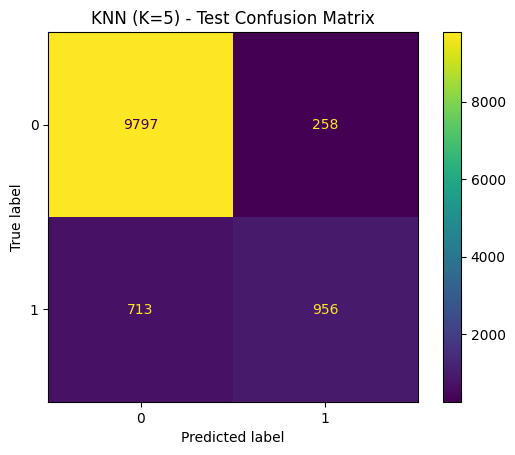

In [ ]:
# confusion matrix for knn
cm = confusion_matrix(y_test, y_pred_knn, labels = knn.classes_)

# display knn confusion matrix
disp = ConfusionMatrixDisplay(cm, display_labels = knn.classes_)
disp.plot()
plt.title("KNN (K=5) - Test Confusion Matrix")
plt.show()

In [ ]:
# classification report for knn
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95     10055
           1       0.79      0.57      0.66      1669

    accuracy                           0.92     11724
   macro avg       0.86      0.77      0.81     11724
weighted avg       0.91      0.92      0.91     11724



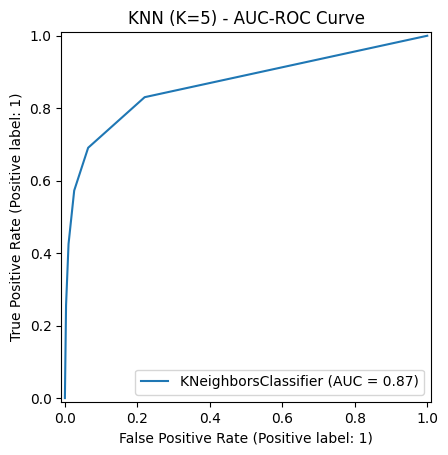

In [ ]:
# auc roc curve for knn
knn_roc = RocCurveDisplay.from_estimator(knn, X_test, y_test)
plt.title("KNN (K=5) - AUC-ROC Curve")
plt.show()

In [ ]:
# print all test scores together for easy comparison
print("======= Test Scores Summary =======")
print()

# accuracy scores for all three models
print("Accuracy:")
print("  NB  :", round(accuracy_score(y_test, y_pred_nb), 4))
print("  LR  :", round(accuracy_score(y_test, y_pred), 4))
print("  KNN :", round(accuracy_score(y_test, y_pred_knn), 4))
print()

======= Test Scores Summary =======

Accuracy:
  NB  : 0.8523
  LR  : 0.8926
  KNN : 0.9172



In [ ]:
# print all test scores together for easy comparison
print("======= Test Scores Summary =======")
print()

# recall scores - important for detecting rejected applications
print("Recall:")
print("  NB  :", round(recall_score(y_test, y_pred_nb), 4))
print("  LR  :", round(recall_score(y_test, y_pred), 4))
print("  KNN :", round(recall_score(y_test, y_pred_knn), 4))
print()

======= Test Scores Summary =======

Recall:
  NB  : 0.6147
  LR  : 0.3829
  KNN : 0.5728



In [ ]:
# print all test scores together for easy comparison
print("======= Test Scores Summary =======")
print()

# precision scores
print("Precision:")
print("  NB  :", round(precision_score(y_test, y_pred_nb), 4))
print("  LR  :", round(precision_score(y_test, y_pred), 4))
print("  KNN :", round(precision_score(y_test, y_pred_knn), 4))
print()

======= Test Scores Summary =======

Precision:
  NB  : 0.4851
  LR  : 0.7362
  KNN : 0.7875



In [ ]:
# print all test scores together for easy comparison
print("======= Test Scores Summary =======")
print()

# f1 scores
print("F1-Score:")
print("  NB  :", round(f1_score(y_test, y_pred_nb), 4))
print("  LR  :", round(f1_score(y_test, y_pred), 4))
print("  KNN :", round(f1_score(y_test, y_pred_knn), 4))
print()

======= Test Scores Summary =======

F1-Score:
  NB  : 0.5423
  LR  : 0.5037
  KNN : 0.6632



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# print all test scores together for easy comparison
print("======= Test Scores Summary =======")
print()

# auc roc scores
print("AUC-ROC:")
print("  NB  :", round(roc_auc_score(y_test, nb.predict_proba(X_test)[:,1]), 4))
print("  LR  :", round(roc_auc_score(y_test, logreg.predict_proba(X_test)[:,1]), 4))
print("  KNN :", round(roc_auc_score(y_test, knn.predict_proba(X_test)[:,1]), 4))

======= Test Scores Summary =======

AUC-ROC:
  NB  : 0.8643
  LR  : 0.8785
  KNN : 0.8673


In [ ]:
# define the parameter grid to search through
# C controls regularisation strength, solver is the optimisation method
param_grid = {'C': [0.01, 0.1, 1, 10, 100],
              'solver': ['lbfgs', 'liblinear'],
              'max_iter': [200, 500, 1000]}

In [ ]:
# set up gridsearchcv with logistic regression and 5 fold cross validation
logreg_gscv = GridSearchCV(LogisticRegression(), param_grid, cv = 5)

# fit gridsearchcv on training data
logreg_gscv.fit(X_train, y_train)

# print the best hyperparameters found
print(logreg_gscv.best_params_)

{'C': 100, 'max_iter': 200, 'solver': 'liblinear'}


In [ ]:
# predict on test set using the tuned model
y_pred_tuned = logreg_gscv.predict(X_test)

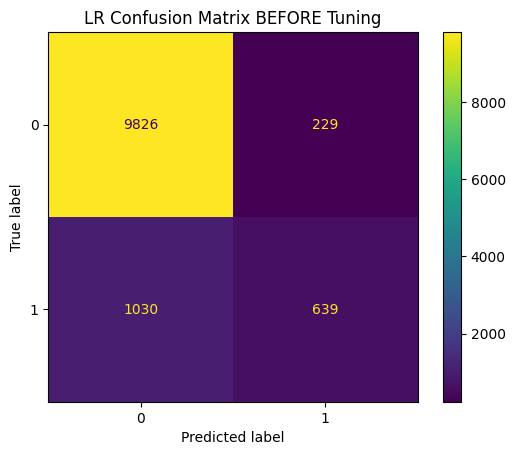

In [ ]:
# plot confusion matrix before tuning
cm_before = confusion_matrix(y_test, y_pred, labels = logreg.classes_)
disp_before = ConfusionMatrixDisplay(cm_before, display_labels = logreg.classes_)
disp_before.plot()
plt.title("LR Confusion Matrix BEFORE Tuning")
plt.show()

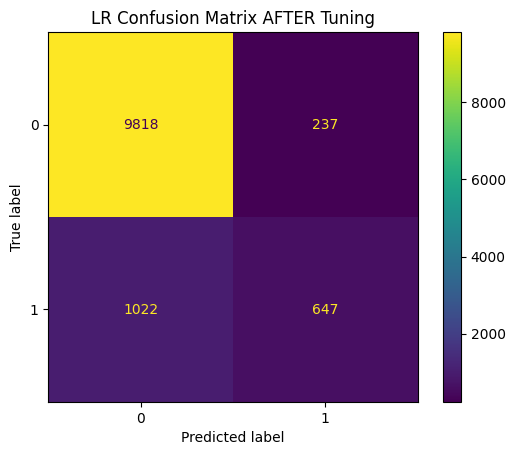

In [ ]:
# plot confusion matrix after tuning
cm_after = confusion_matrix(y_test, y_pred_tuned, labels = logreg.classes_)
disp_after = ConfusionMatrixDisplay(cm_after, display_labels = logreg.classes_)
disp_after.plot()
plt.title("LR Confusion Matrix AFTER Tuning")
plt.show()

In [ ]:
# print classification report before tuning
print("BEFORE Tuning:")
print(classification_report(y_test, y_pred))

BEFORE Tuning:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94     10055
           1       0.74      0.38      0.50      1669

    accuracy                           0.89     11724
   macro avg       0.82      0.68      0.72     11724
weighted avg       0.88      0.89      0.88     11724



In [ ]:
# print classification report after tuning
print("AFTER Tuning:")
print(classification_report(y_test, y_pred_tuned))

AFTER Tuning:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94     10055
           1       0.73      0.39      0.51      1669

    accuracy                           0.89     11724
   macro avg       0.82      0.68      0.72     11724
weighted avg       0.88      0.89      0.88     11724



In [ ]:
# compare recall before and after tuning
print("Recall BEFORE tuning:", round(recall_score(y_test, y_pred), 4))
print("Recall AFTER  tuning:", round(recall_score(y_test, y_pred_tuned), 4))
print()

Recall BEFORE tuning: 0.3829
Recall AFTER  tuning: 0.3877



In [ ]:
# compare precision before and after tuning
print("Precision BEFORE tuning:", round(precision_score(y_test, y_pred), 4))
print("Precision AFTER  tuning:", round(precision_score(y_test, y_pred_tuned), 4))
print()


Precision BEFORE tuning: 0.7362
Precision AFTER  tuning: 0.7319



In [ ]:
# compare f1 score before and after tuning
print("F1 BEFORE tuning:", round(f1_score(y_test, y_pred), 4))
print("F1 AFTER  tuning:", round(f1_score(y_test, y_pred_tuned), 4))

F1 BEFORE tuning: 0.5037
F1 AFTER  tuning: 0.5069


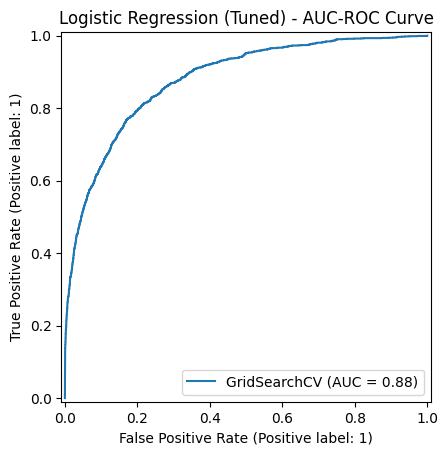

In [ ]:
# plot the auc-roc curve for the tuned logistic regression model
RocCurveDisplay.from_estimator(logreg_gscv, X_test, y_test)
plt.title("Logistic Regression (Tuned) - AUC-ROC Curve")
plt.show()